In [68]:
import pandas as pd

#carregar dados
df = pd.read_csv('../data/vendas.csv')

# visualizar
print(df.head())

         data   produto    categoria  valor  quantidade
0  2024-01-01  Notebook  Eletrônicos   3500           1
1  2024-01-02     Mouse  Eletrônicos     80           2
2  2024-01-03   Cadeira       Móveis    450           1
3  2024-01-04   Teclado  Eletrônicos    150           1
4  2024-01-05      Mesa       Móveis    700           1


In [ ]:
# faturamento total 
print("Faturamento total:" , df["valor"].sum())

# produto mais vendido
print(df["produto"].v())
alue_counts
# média de valor
print("Média de valor:" , df["valor"].mean())

Faturamento total: 6610
produto
Mouse       2
Cadeira     2
Notebook    1
Teclado     1
Mesa        1
Monitor     1
Name: count, dtype: int64
Média de valor: 826.25


# 📊 Análise de Vendas

## 🎯 Objetivo

Analisar dados de vendas para identificar padrões e gerar insights que auxiliem na tomada de decisão.

In [ ]:
import pandas as pd 
df = pd.read_csv("../data/vendas.csv")
df.head()

# faturamento total
df["valor"].sum()

# produtos mais vendidos
df["produto"].value_counts()

# faturamento por categoria
df.groupby("categoria")["valor"].sum()

categoria
Eletrônicos    5010
Móveis         1600
Name: valor, dtype: int64

## 📌 Insights

- A categoria Eletrônicos apresenta o maior faturamento total.
- Produtos de maior valor (como Notebook) impactam significativamente o faturamento.
- Produtos com maior frequência de vendas não necessariamente geram mais receita.

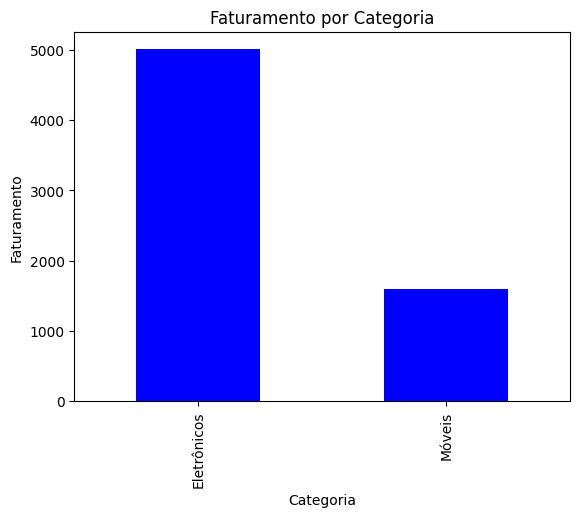

In [71]:
import matplotlib.pyplot as plt
df.groupby("categoria")["valor"].sum().plot(kind="bar" , color="blue")

plt.title("Faturamento por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Faturamento")

plt.show()

## 📊 Faturamento por Categoria

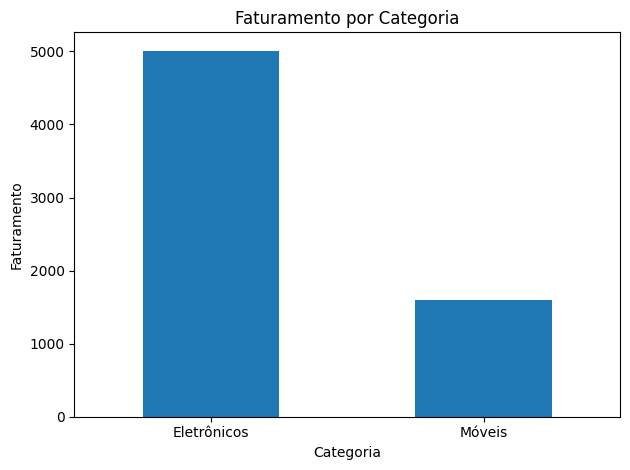

In [72]:
import matplotlib.pyplot as plt

# agrupar faturamento por categoria
faturamento = df.groupby("categoria")["valor"].sum()

# ordenar do maior para o menor
faturamento = faturamento.sort_values(ascending=False)

# criar gráfico de barras
faturamento.plot(kind="bar")

# título e nomes dos eixos
plt.title("Faturamento por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Faturamento")

# ajustar a rotação do eixo
plt.xticks(rotation=0)

# ajustar layout
plt.tight_layout()

# mostrar o gráfico
plt.show()

## 📌 Insight

- A categoria Eletrônicos gera a maior parte do faturamento.
- Móveis possuem menor participação nas vendas totais.

## 📊 Faturamento por Produto

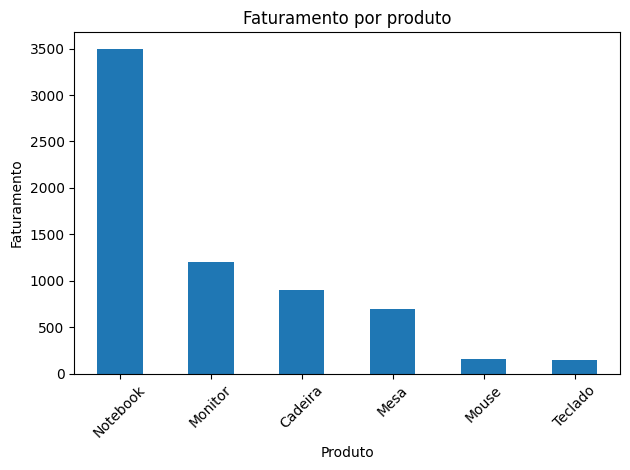

In [73]:
import matplotlib.pyplot as plt

# agrupar faturamento por produto
faturamento_produto = df.groupby("produto")["valor"].sum()

# ordenar do maior para o menor
faturamento_produto = faturamento_produto.sort_values(ascending=False)

# criar o gráfico
faturamento_produto.plot(kind="bar")

# títulos
plt.title("Faturamento por produto")
plt.xlabel("Produto")
plt.ylabel("Faturamento")

# girar nomes (porque são nomes longos)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 📌 Insight

- O produto com maior faturamento é o Notebook.
- Produtos mais baratos aparecem com maior frequência, mas não geram tanta receita.

## 📊 Quantidade vs Faturamento por Produto

In [74]:
import matplotlib.pyplot as plt

# quantidade de vendas por produto
quantidade = df["produto"].value_counts()

# faturamento por produto
faturamento = df.groupby("produto")["valor"].sum()

# juntar as duas informações 
comparacao = pd.DataFrame({
    "quantidade": quantidade,
    "faturamento": faturamento
})

# ordenar por faturamento
comparacao = comparacao.sort_values(by="faturamento" , ascending=False)

print(comparacao)

          quantidade  faturamento
produto                          
Notebook           1         3500
Monitor            1         1200
Cadeira            2          900
Mesa               1          700
Mouse              2          160
Teclado            1          150


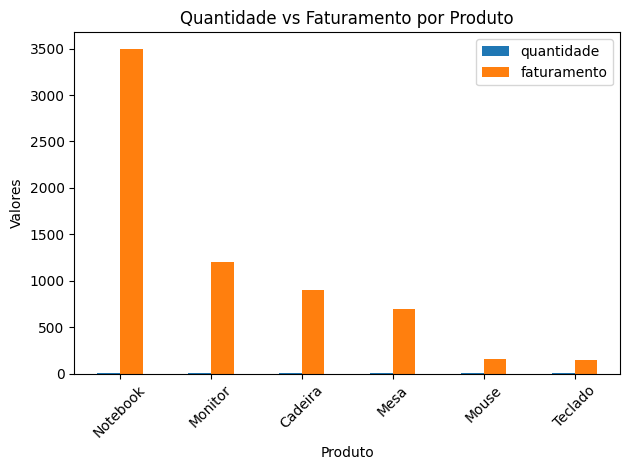

In [75]:
comparacao.plot(kind="bar")

plt.title("Quantidade vs Faturamento por Produto")
plt.xlabel("Produto")
plt.ylabel("Valores")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 📊 Resumo Executivo de Vendas

Este dashboard apresenta uma análise comparativa entre:

- 💰 Faturamento por produto
- 📦 Volume de vendas

# 🎯 Objetivo:
Identificar quais produtos:
- Geram mais receita
- Vendem mais em quantidade
- Possuem potencial de otimização

# 📌 Principais perguntas:
- Produto que mais fatura é o que mais vende?
- Existe produto com alto volume mas baixo faturamento?

In [76]:
comparacao["ticket_medio"] = comparacao["faturamento"] / comparacao["quantidade"]

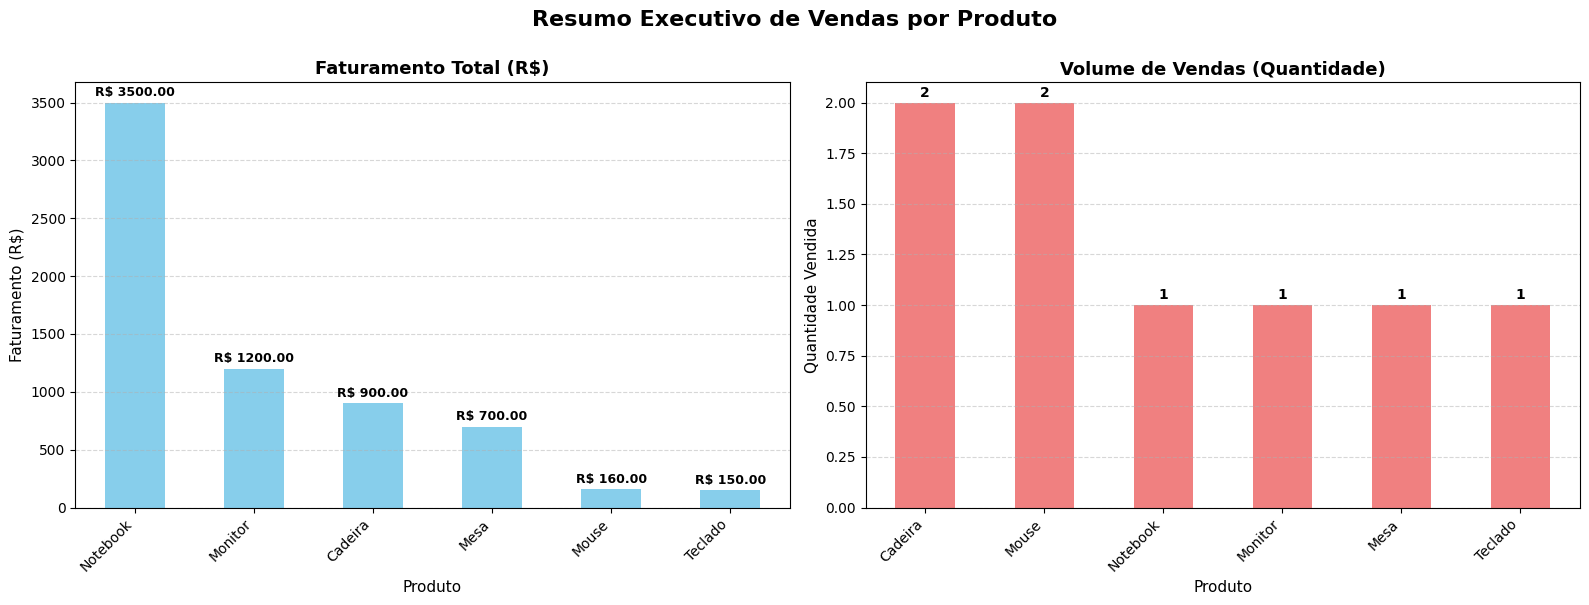

In [77]:
import matplotlib.pyplot as plt

# configurar os dados (usando o meu df "comparacao")
# garantir que está ordenado por faturamento para o primeiro gráfico
comparacao = comparacao.sort_values(by="faturamento", ascending=False)

# criar a estrutura do subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# título principal do dashboard
fig.suptitle("Resumo Executivo de Vendas por Produto", fontsize=16, fontweight='bold', y=1.0)

# gráfico 1: Faturamento por Produto (lado esquerdo - axes[0])
faturamento_plot = comparacao["faturamento"].plot(kind="bar", ax=axes[0], color="skyblue")
axes[0].set_title("Faturamento Total (R$)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Faturamento (R$)", fontsize=11)
axes[0].set_xlabel("Produto", fontsize=11)
axes[0].set_xticklabels(comparacao.index, rotation=45, ha='right') # melhora a legibilidade
axes[0].grid(axis='y', linestyle='--', alpha=0.5) # adiciona uma grade suave

# adicionar os valores exatos em cima das barras
for p in faturamento_plot.patches:
    axes[0].annotate(f'R$ {p.get_height():.2f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 7),
                     textcoords='offset points', fontsize=9, fontweight='bold')

# gráfico 2: Quantidade Vendida (lado direito - axes[1])
# ordenar por quantidade para o segundo gráfico ficar mais lógico
quantidade_ordenada = comparacao["quantidade"].sort_values(ascending=False)
quantidade_plot = quantidade_ordenada.plot(kind="bar", ax=axes[1], color="lightcoral")
axes[1].set_title("Volume de Vendas (Quantidade)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Quantidade Vendida", fontsize=11)
axes[1].set_xlabel("Produto", fontsize=11)
axes[1].set_xticklabels(quantidade_ordenada.index, rotation=45, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# adicionar os valores exatos em cima das barras de quantidade
for p in quantidade_plot.patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 7),
                     textcoords='offset points', fontsize=10, fontweight='bold')
    
# ajustar o layout para não cortar nada
plt.tight_layout()

# mostrar o dashboard
plt.show()

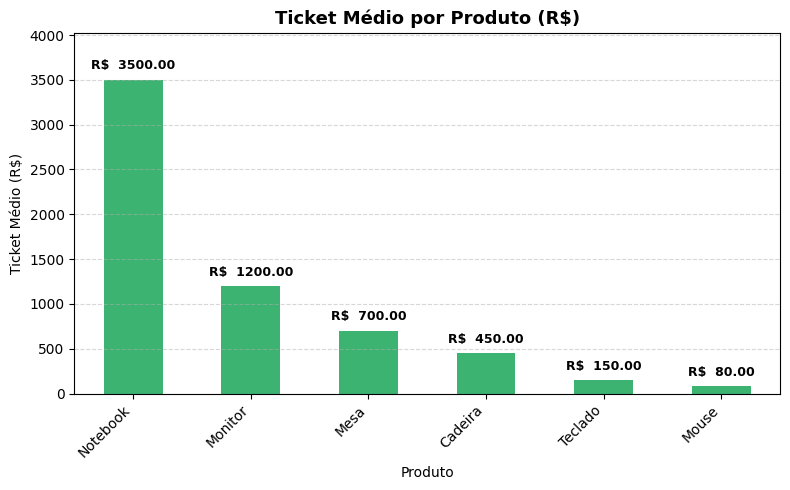

In [78]:
ticket_plot = comparacao["ticket_medio"].sort_values(ascending=False).plot (kind="bar", figsize=(8,5), color="mediumseagreen")

plt.title("Ticket Médio por Produto (R$)", fontsize=13, fontweight='bold')
plt.ylabel("Ticket Médio (R$)")
plt.xlabel("Produto")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle= '--', alpha=0.5)

# valores nas barras
for p in ticket_plot.patches:
    plt.annotate(f'R$ {p.get_height(): .2f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 10),
                 textcoords='offset points', fontsize=9, fontweight='bold')

plt.ylim(0, comparacao["ticket_medio"].max() * 1.15)    
plt.tight_layout()
plt.show()


📈 Insights

- Produtos com maior faturamento nem sempre são os mais vendidos
- Existe diferença entre volume e valor (estratégia de preço)
- Produtos com alto ticket médio podem indicar maior margem

💡 Possíveis ações:
- Focar marketing nos produtos de maior ticket médio
- Criar promoções para produtos de baixo volume
- Avaliar precificação dos produtos mais vendidos